# DREAMS Interpolated QSTS Hosting Capacity with Asset Profiles

With the interpolated hosting capacity approach, it is possible to use
profiles that modify the added asset's contribution to the system.

This is useful to model the temporal interactions between demand and
generation assocaited with, for example, PV geneartion or Large load
time-of-use schedules.

It should be noted that this method is still experimental and being refined.
Currently, the method is designed to study 3-phase medium voltage buses.

In [1]:
import dreams

from pathlib import Path
import os
import pandas as pd
import matplotlib.pyplot as plt


# Define Paths
Similar to the previous demo, the feeder used here is the synthetic bay 
area feeder with a single time series demand profile for all loads.

In [2]:
model_dir = Path(r'models') / 'sfo_p1udt1469'
profile_dir  = Path(r'models') / 'generic_profiles'

output_dir = model_dir / 'temp_outputs'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Select Buses
This method is designed for 3-phase medium voltage locations.
While the approach is valid for other locations, extra considerations would
have to be accounted for that is beyond the scope of this demo and current 
code base.

In [3]:
feeder = dreams.Feeder(model_dir/'Main_with_profile.dss', name='sfo_p1udt1469')

In [4]:
buses_to_test = [
    'p1udt888',
    'p1udt222',
    'p1udt16',
    'p1udt333',
    'p1udt440',
    ]
feeder.buses.loc[buses_to_test]

,longitude,latitude,n_phases,phases,kv_base,primary,distance
name,,,,,,,
p1udt888,-122.393607,37.752482,3,123,7.199558,True,0.430128
p1udt222,-122.395315,37.752391,3,123,7.199558,True,0.584205
p1udt16,-122.398544,37.757311,3,123,7.199558,True,1.365715
p1udt333,-122.401206,37.760912,3,123,7.199558,True,1.918593
p1udt440,-122.401268,37.764125,3,123,7.199558,True,2.462179


# Import Time series for Shape Creation
This demo will utilize generic time series data that are used to create
Shape objects to simulate:
irradiance, windspeed, and demand time-of-use

The below process also normalizes the irradiance and wind speed data 
according to typical values.

In [5]:
os.listdir(profile_dir)

['generic_15min_mps.csv',
 'generic_15min_tou.csv',
 'generic_15min_wpm2.csv',
 'readme.txt']

Text(0.5, 1.0, 'PU Irradiance')

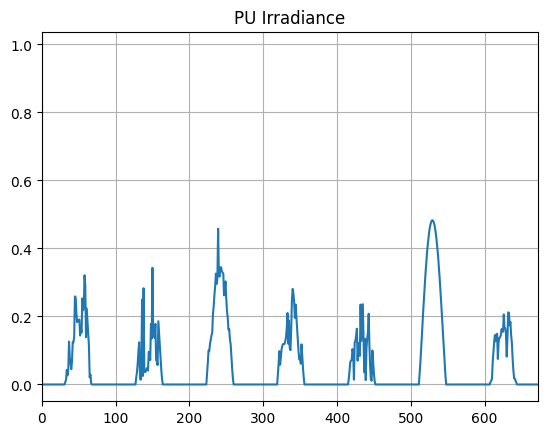

In [6]:
irradiance_profile = dreams.Shape(
    profile_dir/'generic_15min_wpm2.csv',
    'generic_irradiance',
    hour_interval=15/60,
    column=0,
    mode='duty',
    )
irradiance_profile.data /= 1000  # to ensure PU
ax = irradiance_profile.data.plot()
ax.set_xlim([0, 24*4*7])
ax.grid(True)
ax.set_title('PU Irradiance')

Text(0.5, 1.0, 'PU Wind')

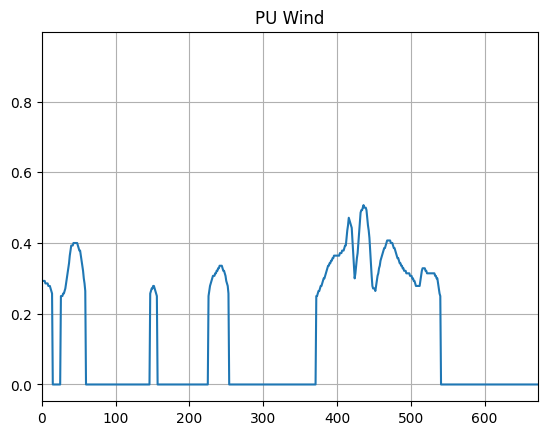

In [7]:
wind_profile = dreams.Shape(
    profile_dir/'generic_15min_mps.csv',
    'generic_wind',
    hour_interval=15/60,
    column=0,
    mode='duty',
    )

# modify raw profile to PU while accounting for cut in and out
cut_in = 3.5
cut_out = 25
rated = 14

under_cut_in = wind_profile.data < cut_in
over_cut_out = wind_profile.data > cut_out
no_gen = under_cut_in | over_cut_out

wind_profile.data /= rated
wind_profile.data[no_gen] = 0
ax = wind_profile.data.plot()
ax.set_xlim([0, 24*4*7])
ax.grid(True)
ax.set_title('PU Wind')

Text(0.5, 1.0, 'PU Time-of-use Demand')

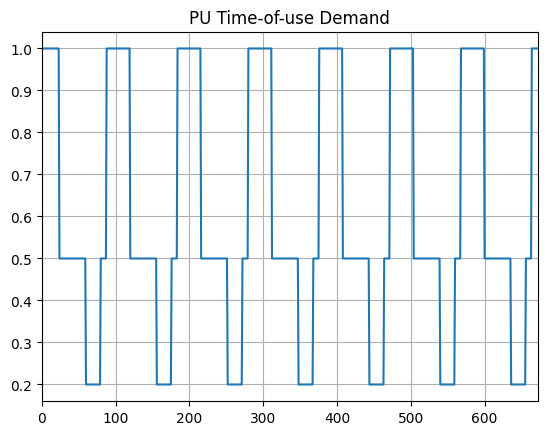

In [8]:
tou_profile = dreams.Shape(
    profile_dir/'generic_15min_tou.csv',
    'generic_tou',
    hour_interval=15/60,
    column=0,
    mode='duty',
    )

ax = tou_profile.data.plot()
ax.set_xlim([0, 24*4*7])

ax.grid(True)
ax.set_title('PU Time-of-use Demand')

# Run interpolated generation hosting capacity
The `QSTS_HC` method accepts all simulation parameters and returns an 
object that contains results and timings.

For this demo, a constant simulation is run, followed by one with a profile.
This is so that the constant interpolated results can be compared to 
snapshot results, and then the interpolated profile results can be 
compared to the constant interpolated results to show how a profile may
affect hosting capacity.

In [9]:
constant_power_res = dreams.hc.interp.QSTS_HC(
    feeder,
    buses_to_test,
    output_dir=output_dir,
    kind='gen',
    step_size_seconds=60*15,  # 15 minute profile
    total_time_steps=24*4*7,  # run for 7 days
    name='constant_power'
)

** Bus 5/5 


In [10]:
pv_profile_res = dreams.hc.interp.QSTS_HC(
    feeder,
    buses_to_test,
    output_dir=output_dir,
    kind='gen',
    asset_shape=irradiance_profile,
    step_size_seconds=60*15,  # 15 minute profile
    total_time_steps=24*4*7,  # run for 7 days
    name='pv_profile'
)

** Bus 5/5 


In [11]:
wind_profile_res = dreams.hc.interp.QSTS_HC(
    feeder,
    buses_to_test,
    output_dir=output_dir,
    kind='gen',
    asset_shape=wind_profile,
    step_size_seconds=60*15,  # 15 minute profile
    total_time_steps=24*4*7,  # run for 7 days
    name='wind_profile',
)

** Bus 5/5 


# Run Snapshot hosting capacity to validate results

As in the previous demo, for each interpolated result, a snapshot hosting 
capacity is also calculated to validate the interpolated hosting 
capacity results.

In [12]:
feeder = dreams.Feeder(model_dir/'Main_with_profile.dss', name='sfo_p1udt1469')

snap_shot_res = []

time_step = 60*15  # 15 minutes per step

for bus_name, row in constant_power_res.result_df.iterrows():
    # create times to test from interpolated results
    print(bus_name)
    vchc_t = row['vchc_ndx'] * time_step
    tchc_t = row['tchc_ndx'] * time_step

    bus_res = dreams.hc.NodalSnapshot(
        feeder,
        bus_names=[bus_name],
        constraint='voltage',
        hc_kind='gen',
        mode='duty',
        at_sec=vchc_t,
        save_violations=True
    )

    # generation will typically lead to over voltage violations
    vchc_element = bus_res.violations[bus_name]['over_voltage']['Bus_Name'].values[0]
    bus_res.result_df['voltage_element'] = vchc_element

    thermal_bus_res = dreams.hc.NodalSnapshot(
        feeder,
        bus_names=[bus_name],
        constraint='thermal',
        hc_kind='gen',
        mode='duty',
        at_sec=tchc_t,
        save_violations=True,
    )

    thermal_element = thermal_bus_res.violations[bus_name]['over_capacity']['Name'].values[0]
    bus_res.result_df['thermal_hc_kw'] = thermal_bus_res.result_df['thermal_hc_kw']
    bus_res.result_df['thermal_element'] = thermal_element

    snap_shot_res.append(bus_res.result_df)

nodal_gen_hc = pd.concat(snap_shot_res)

p1udt888
Started voltage constrained hosting capacity
Bus 1/1  (100.00% complete in 2.67 seconds)  
Started thermal constrained hosting capacity
Bus 1/1  (100.00% complete in 3.19 seconds)  
p1udt222
Started voltage constrained hosting capacity
Bus 1/1  (100.00% complete in 2.33 seconds)  
Started thermal constrained hosting capacity
Bus 1/1  (100.00% complete in 2.78 seconds)  
p1udt16
Started voltage constrained hosting capacity
Bus 1/1  (100.00% complete in 2.62 seconds)  
Started thermal constrained hosting capacity
Bus 1/1  (100.00% complete in 3.05 seconds)  
p1udt333
Started voltage constrained hosting capacity
Bus 1/1  (100.00% complete in 2.98 seconds)  
Started thermal constrained hosting capacity
Bus 1/1  (100.00% complete in 2.80 seconds)  
p1udt440
Started voltage constrained hosting capacity
Bus 1/1  (100.00% complete in 2.62 seconds)  
Started thermal constrained hosting capacity
Bus 1/1  (100.00% complete in 3.08 seconds)  


# Generation Hosting Capacity Result Comparisons
For a clearer, immediate comparison of profile impacts, the below plots
show how the snapshot and constant results are very similar - which
validates the interpolation method, and then the Wind and PV results
are different from the constant asset profile result.

In this example, the results show that applying a reasonable generation
profile to the hosting capacity asset reveals that more capacity is
available.

Text(0.5, 0, 'Distance from Substation [km]')

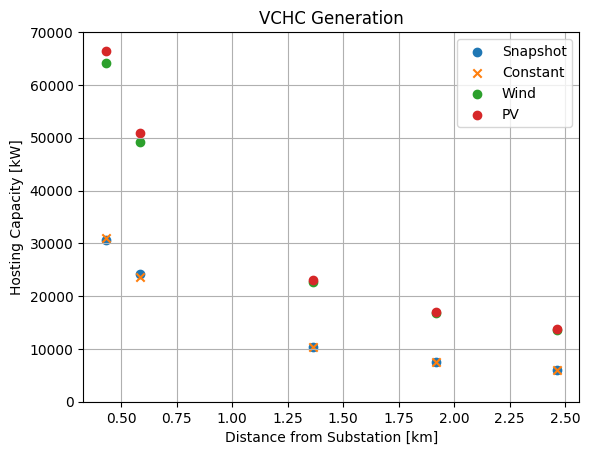

In [13]:
fig, ax = plt.subplots()

ax.scatter(nodal_gen_hc['bus_dist_km'], nodal_gen_hc['voltage_hc_kw'])
ax.scatter(constant_power_res.result_df['distance_from_sub'], constant_power_res.result_df['vchc'], marker='x')
ax.scatter(wind_profile_res.result_df['distance_from_sub'], wind_profile_res.result_df['vchc'])
ax.scatter(pv_profile_res.result_df['distance_from_sub'], pv_profile_res.result_df['vchc'])


ax.set_ylim([0,70e3])
ax.legend(['Snapshot', 'Constant', 'Wind', 'PV'])
ax.grid()
ax.set_title('VCHC Generation')
ax.set_ylabel('Hosting Capacity [kW]')
ax.set_xlabel('Distance from Substation [km]')

Text(0.5, 0, 'Distance from Substation [km]')

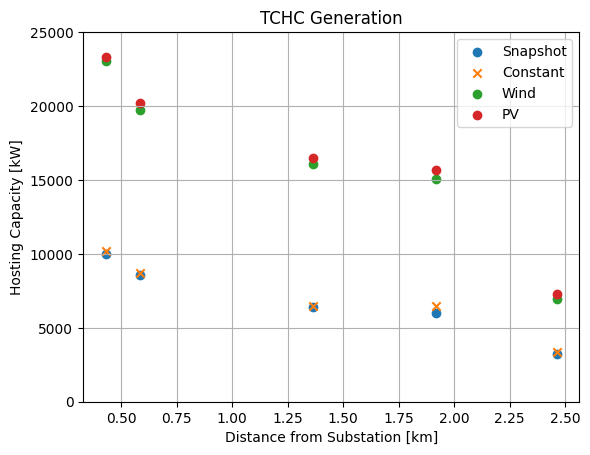

In [14]:
fig, ax = plt.subplots()

ax.scatter(nodal_gen_hc['bus_dist_km'], nodal_gen_hc['thermal_hc_kw'])
ax.scatter(constant_power_res.result_df['distance_from_sub'], constant_power_res.result_df['tchc'], marker='x')
ax.scatter(wind_profile_res.result_df['distance_from_sub'], wind_profile_res.result_df['tchc'])
ax.scatter(pv_profile_res.result_df['distance_from_sub'], pv_profile_res.result_df['tchc'])

ax.set_ylim([0,25e3])
ax.legend(['Snapshot', 'Constant', 'Wind', 'PV'])
ax.grid()
ax.set_title('TCHC Generation')
ax.set_ylabel('Hosting Capacity [kW]')
ax.set_xlabel('Distance from Substation [km]')


Detailed results from the generation hosting capacity are printed below,
with high level take aways being:

Constant power results are close to the nodal snapshot results, this is
expected as they are meant to be equivalent.

In general, the profiles identified different critical time steps in which
violations occur.
This is due to the non-constant profiles used.

Using profiles results in different, typically higher VCHC - due to:
1. Effective de-rating of asset due to non-perfect (more realistic) output
2. temporal interactions (no pv generation at night and intermittent 
wind generation)

SCHC is much higher as it:
1. Avoids unrealistic overnight lows when PV is inactive.
2. Includes de-rating of asset due to non-perfect (more realistic) output

In [15]:
nodal_gen_hc[['voltage_hc_kw', 'thermal_hc_kw', 'voltage_element', 'thermal_element',]]

,voltage_hc_kw,thermal_hc_kw,voltage_element,thermal_element
p1udt888,30695,9976,p1udt203-p1udt365x,Line.PADSWITCH(R:P1UDT940-P1UDT941)P1U_9557
p1udt222,24188,8574,p1udt222,Line.L(R:P1UDT222-P1UDT885)
p1udt16,10350,6388,p1udt16,Line.PADSWITCH(R:P1UDT237-P1UDT256)P1U_9370
p1udt333,7457,6026,p1udt333,Line.PADSWITCH(R:P1UDT229-P1UDT342)P1U_9260
p1udt440,5932,3214,p1udt440,Line.PADSWITCH(R:P1UDT158-P1UDT99)P1U_9240


In [16]:
constant_power_res.result_df[['vchc','tchc','vchc_element','vchc_ndx', 'tchc_element', 'schc']]


,vchc,tchc,vchc_element,vchc_ndx,tchc_element,schc
bus_name,,,,,,
p1udt888,31023.383412,10161.308300,p1udt888,492,l(r:p1udt1469-p1uhs0_1247),2867.437751
p1udt222,23587.075438,8721.530201,p1udt222,492,padswitch(r:p1udt222-p1udt885)p1u_9412,2867.550763
p1udt16,10418.200757,6490.894538,p1udt16,492,padswitch(r:p1udt251-p1udt252)p1u_9375,2871.751067
p1udt333,7597.912892,6489.024660,p1udt333,492,padswitch(r:p1udt251-p1udt252)p1u_9375,2877.697669
p1udt440,6080.389710,3383.940218,p1udt440,492,padswitch(r:p1udt158-p1udt99)p1u_9240,2886.182660


In [17]:
wind_profile_res.result_df[['vchc','tchc','vchc_element', 'vchc_ndx','tchc_element', 'schc']]


,vchc,tchc,vchc_element,vchc_ndx,tchc_element,schc
bus_name,,,,,,
p1udt888,64135.078627,23023.101730,p1udt888,437,l(r:p1udt1469-p1uhs0_1247),8183.914017
p1udt222,49270.465253,19711.165666,p1udt222,437,padswitch(r:p1udt222-p1udt885)p1u_9412,8177.571956
p1udt16,22640.287571,16102.589609,p1udt16,437,padswitch(r:p1udt251-p1udt252)p1u_9375,8155.553643
p1udt333,16784.346457,15042.021163,p1udt333,437,padswitch(r:p1udt333-p1udt372)p1u_9248,8152.320677
p1udt440,13523.064520,6954.437332,p1udt440,437,padswitch(r:p1udt158-p1udt99)p1u_9240,8162.404685


In [18]:
pv_profile_res.result_df[['vchc','tchc','vchc_element', 'vchc_ndx', 'tchc_element', 'schc']]

,vchc,tchc,vchc_element,vchc_ndx,tchc_element,schc
bus_name,,,,,,
p1udt888,66401.909741,23327.956495,p1udt888,530,l(r:p1udt1469-p1uhs0_1247),7874.384887
p1udt222,50862.122113,20181.468438,p1udt222,530,padswitch(r:p1udt222-p1udt885)p1u_9412,7868.998759
p1udt16,23103.911878,16475.065917,p1udt16,530,padswitch(r:p1udt251-p1udt252)p1u_9375,7850.736262
p1udt333,17042.769510,15678.046182,p1udt333,530,padswitch(r:p1udt333-p1udt372)p1u_9248,7848.668841
p1udt440,13697.087452,7259.769910,p1udt440,530,padswitch(r:p1udt158-p1udt99)p1u_9240,7858.247890


# Run interpolated demand hosting capacity
Demand, or load, hosting capacity is configured in a similar fashion as 
generation hosting capacity, though the `kind` variable is set to `load`.

In [19]:
constant_load_res = dreams.hc.interp.QSTS_HC(
    feeder,
    buses_to_test,
    output_dir=output_dir,
    kind='load',
    step_size_seconds=60*15,  # 15 minute profile
    total_time_steps=24*4*7,  # run for 7 days
    name='constant_demand'
)

** Bus 5/5 


In [20]:
tou_load_res = dreams.hc.interp.QSTS_HC(
    feeder,
    buses_to_test,
    output_dir=output_dir,
    kind='load',
    asset_shape=tou_profile,
    step_size_seconds=60*15,  # 15 minute profile
    total_time_steps=24*4*7,  # run for 7 days
    name='tou_profile',

)

** Bus 5/5 


In [21]:
feeder = dreams.Feeder(model_dir/'Main_with_profile.dss', name='sfo_p1udt1469')

snap_shot_res = []

time_step = 60*15  # 15 minutes per step

for bus_name, row in constant_load_res.result_df.iterrows():
    # create times to test from interpolated results
    print(bus_name)
    vchc_t = row['vchc_ndx'] * time_step
    tchc_t = row['tchc_ndx'] * time_step

    bus_res = dreams.hc.NodalSnapshot(
        feeder,
        bus_names=[bus_name],
        constraint='voltage',
        hc_kind='load',
        mode='duty',
        at_sec=vchc_t,
        save_violations=True
    )

    # generation will typically lead to over voltage violations
    vchc_element = bus_res.violations[bus_name]['under_voltage']['Bus_Name'].values[0]
    bus_res.result_df['voltage_element'] = vchc_element

    thermal_bus_res = dreams.hc.NodalSnapshot(
        feeder,
        bus_names=[bus_name],
        constraint='thermal',
        hc_kind='load',
        mode='duty',
        at_sec=tchc_t,
        save_violations=True,
    )

    thermal_element = thermal_bus_res.violations[bus_name]['over_capacity']['Name'].values[0]
    bus_res.result_df['thermal_hc_kw'] = thermal_bus_res.result_df['thermal_hc_kw']
    bus_res.result_df['thermal_element'] = thermal_element

    snap_shot_res.append(bus_res.result_df)

nodal_load_hc = pd.concat(snap_shot_res)

p1udt888
Started voltage constrained hosting capacity
Bus 1/1  (100.00% complete in 3.50 seconds)  
Started thermal constrained hosting capacity
Bus 1/1  (100.00% complete in 3.22 seconds)  
p1udt222
Started voltage constrained hosting capacity
Bus 1/1  (100.00% complete in 2.94 seconds)  
Started thermal constrained hosting capacity
Bus 0/1  (0.00% complete)  Cound't remove capacity_1784841100_2038395.csv due to a permission error...
Bus 1/1  (100.00% complete in 3.09 seconds)  
p1udt16
Started voltage constrained hosting capacity
Bus 1/1  (100.00% complete in 2.92 seconds)  
Started thermal constrained hosting capacity
Bus 1/1  (100.00% complete in 3.11 seconds)  
p1udt333
Started voltage constrained hosting capacity
Bus 1/1  (100.00% complete in 3.08 seconds)  
Started thermal constrained hosting capacity
Bus 1/1  (100.00% complete in 3.38 seconds)  
p1udt440
Started voltage constrained hosting capacity
Bus 1/1  (100.00% complete in 3.11 seconds)  
Started thermal constrained hostin

# Demand Hosting Capacity Result Comparisons
Again, plots are presented before detailed tables are printed.
While there is some error in the VCHC results, the TOU profile does
apear to allow larger loads to be connected at tested buses.

The interpolated TCHC results from a constant load match very well to 
the snapshot results as the critical element was identified in all cases.
The TOU profile increased TCHC by 500-1,000 kW at the tested buses.

Text(0.5, 0, 'Distance from Substation [km]')

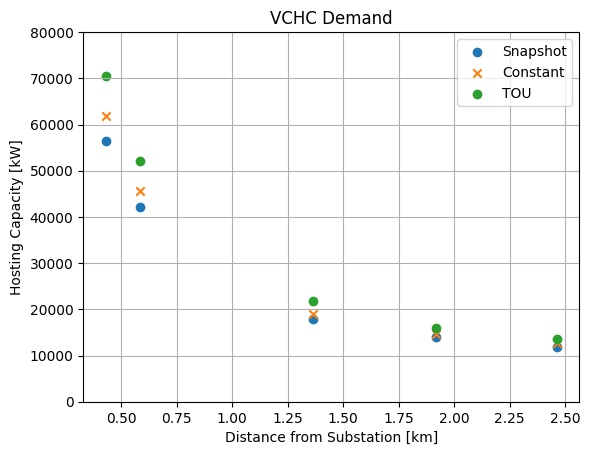

In [22]:
fig, ax = plt.subplots()

ax.scatter(nodal_load_hc['bus_dist_km'], nodal_load_hc['voltage_hc_kw'])
ax.scatter(constant_load_res.result_df['distance_from_sub'], constant_load_res.result_df['vchc'], marker='x')
ax.scatter(tou_load_res.result_df['distance_from_sub'], tou_load_res.result_df['vchc'])
ax.set_ylim([0,80e3])
ax.legend(['Snapshot', 'Constant', 'TOU'])
ax.grid()
ax.set_title('VCHC Demand')
ax.set_ylabel('Hosting Capacity [kW]')
ax.set_xlabel('Distance from Substation [km]')

Text(0.5, 0, 'Distance from Substation [km]')

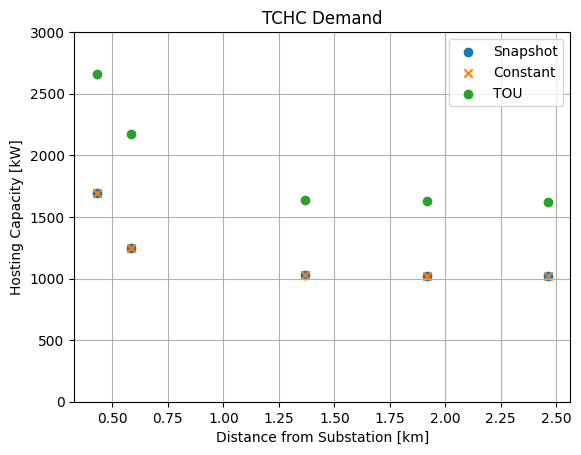

In [23]:
fig, ax = plt.subplots()

ax.scatter(nodal_load_hc['bus_dist_km'], nodal_load_hc['thermal_hc_kw'])
ax.scatter(constant_load_res.result_df['distance_from_sub'], constant_load_res.result_df['tchc'], marker='x')
ax.scatter(tou_load_res.result_df['distance_from_sub'], tou_load_res.result_df['tchc'])
ax.set_ylim([0,3e3])
ax.legend(['Snapshot', 'Constant', 'TOU'])
ax.grid()
ax.set_title('TCHC Demand')
ax.set_ylabel('Hosting Capacity [kW]')
ax.set_xlabel('Distance from Substation [km]')


In [24]:
nodal_load_hc[['voltage_hc_kw', 'thermal_hc_kw', 'voltage_element', 'thermal_element',]].head()

,voltage_hc_kw,thermal_hc_kw,voltage_element,thermal_element
p1udt888,56528,1694,p1ulv573,Line.L(R:P1UDT1469-P1UHS0_1247)
p1udt222,42153,1244,p1ulv573,Line.PADSWITCH(R:P1UDT885-P1UDT888)P1U_9546
p1udt16,17903,1031,p1ulv573,Line.PADSWITCH(R:P1UDT251-P1UDT252)P1U_9375
p1udt333,13921,1024,p1ulv1083,Line.PADSWITCH(R:P1UDT251-P1UDT252)P1U_9375
p1udt440,11879,1020,p1ulv248,Line.PADSWITCH(R:P1UDT251-P1UDT252)P1U_9375


In [25]:
constant_load_res.result_df[['vchc','vchc_element', 'vchc_ndx', 'tchc', 'tchc_element','tchc_ndx']].head()

,vchc,vchc_element,vchc_ndx,tchc,tchc_element,tchc_ndx
bus_name,,,,,,
p1udt888,61761.504854,p1ulv573.1.2,79,1692.808743,l(r:p1udt1469-p1uhs0_1247),79.0
p1udt222,45658.235907,p1ulv573.1.2,79,1244.547376,padswitch(r:p1udt885-p1udt888)p1u_9546,79.0
p1udt16,19017.502598,p1ulv573.1.2,79,1030.659314,padswitch(r:p1udt251-p1udt252)p1u_9375,79.0
p1udt333,14665.822106,p1ulv1083.1.2,79,1023.564739,padswitch(r:p1udt251-p1udt252)p1u_9375,79.0
p1udt440,12659.191484,p1ulv1866.1.2.3,79,1019.718902,padswitch(r:p1udt251-p1udt252)p1u_9375,79.0


In [26]:
tou_load_res.result_df[['vchc','vchc_element', 'vchc_ndx', 'tchc', 'tchc_element','tchc_ndx']].head()

,vchc,vchc_element,vchc_ndx,tchc,tchc_element,tchc_ndx
bus_name,,,,,,
p1udt888,70531.212824,p1ulv573.1.2,24,2657.898488,l(r:p1udt1469-p1uhs0_1247),24.0
p1udt222,52153.315655,p1ulv573.1.2,24,2169.793543,padswitch(r:p1udt885-p1udt888)p1u_9546,24.0
p1udt16,21753.361981,p1ulv573.1.2,24,1637.448928,padswitch(r:p1udt251-p1udt252)p1u_9375,24.0
p1udt333,16033.677580,p1ulv1083.1.2,24,1625.574036,padswitch(r:p1udt251-p1udt252)p1u_9375,24.0
p1udt440,13534.199987,p1ulv1866.1.2.3,24,1618.026346,padswitch(r:p1udt251-p1udt252)p1u_9375,24.0


# Conclusion
As above results show, using profiles can increase hosting capacity results.
However, the mechanism of this reduction relies on the asset not exceeding
the provided profile.
While this may be obvious, care should be taken to describe the assumptions - 
especially when describing time-of-use demand profiles.